In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import scanpy as sc
import os
from dotenv import load_dotenv; load_dotenv()
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
from itertools import product
import ast

from utils import preprocessing


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
slidetags = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags.h5ad", backed="r")
nucseq = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad", backed="r"    )

In [ ]:
# Same gene format
nucseq.var.index = nucseq.var["gene_symbol"]
slidetags.var.index = slidetags.var["gene_symbol"]

# Gene markers: D1 Matrix

In [8]:
ZONE_COL = "zone"           # <-- adjust
CONDITION_COL = "condition"  # <-- adjust
HEALTHY_LABEL = "Ctrl"       # <-- adjust
DISEASE_LABEL = "XDP"        # <-- adjust

In [11]:
mask = (
    nucseq.obs["Group_name"].isin(["STRd D1 Matrix MSN", "STRv D1 MSN"]) & # only D1
    (nucseq.obs["ct_for_deg"] == "Matrix") &# only QC cells
    (nucseq.obs["zone"].notna())
)
nucseq_d1_matrix = nucseq[mask].to_memory().copy()

mask = (
    slidetags.obs["Group_name"].isin(["STRd D1 Matrix MSN", "STRv D1 MSN"]) &# only D1
    (slidetags.obs["zone"].notna()) # only QC cells
)
slidetag_d1_matrix = slidetags[mask].to_memory().copy()

ref_d1_matrix_zoning = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/STR_zonation_references_h5ad/STR_D1_Matrix_MSN.h5ad")
ref_d1_matrix_zoning.obs["zone"] = ref_d1_matrix_zoning.obs["Final_Zone_Assignments_No_Smooth"]#"Final_Zone_Assignments_No_Smooth"]
ref_d1_matrix_zoning.obs[CONDITION_COL] = HEALTHY_LABEL

In [12]:
CONDITION_MAP = {
    "healthy": HEALTHY_LABEL, "diseased": DISEASE_LABEL,
    "Control": HEALTHY_LABEL, "XDP": DISEASE_LABEL,
    HEALTHY_LABEL: HEALTHY_LABEL, DISEASE_LABEL: DISEASE_LABEL,
}

# ── SET raw counts in X ───────────────────────────────────────────────────────
nucseq_d1_matrix.X        = nucseq_d1_matrix.layers["counts"].copy()
slidetag_d1_matrix.X      = slidetag_d1_matrix.layers["counts"].copy()

# ── TAG modality ──────────────────────────────────────────────────────────────
nucseq_d1_matrix.obs["modality"]     = "NucSeq"
slidetag_d1_matrix.obs["modality"]   = "Slidetags"
ref_d1_matrix_zoning.obs["modality"] = "Ref"

# ── ALIGN var_names to gene symbols ──────────────────────────────────────────
slidetag_d1_matrix.obs.rename(columns={"state": CONDITION_COL}, inplace=True)
slidetag_d1_matrix.var_names = slidetag_d1_matrix.var["gene_symbol"].astype(str)
# nucseq + ref: var_names already = gene symbols ✅

# ── STANDARDIZE condition + zone, drop duplicates ────────────────────────────
for adata in [nucseq_d1_matrix, slidetag_d1_matrix, ref_d1_matrix_zoning]:
    adata.obs[CONDITION_COL] = adata.obs[CONDITION_COL].map(CONDITION_MAP).astype("category")
    adata.obs[ZONE_COL]      = adata.obs[ZONE_COL].astype("category")
    adata                    = adata[:, ~adata.var_names.duplicated()]

# ── GENE INTERSECTION across all 3 ───────────────────────────────────────────
common_genes = (
    set(nucseq_d1_matrix.var_names)
    & set(slidetag_d1_matrix.var_names)
    & set(ref_d1_matrix_zoning.var_names)
)
print(f"Common genes (3-way): {len(common_genes)}")

# ── VERIFY ────────────────────────────────────────────────────────────────────
for name, adata in [("NucSeq", nucseq_d1_matrix), ("Slidetags", slidetag_d1_matrix), ("Ref", ref_d1_matrix_zoning)]:
    print(f"\n{name}: {adata.n_obs} cells | condition: {adata.obs[CONDITION_COL].unique().tolist()} | zones: {sorted(adata.obs[ZONE_COL].dropna().unique().tolist())}")

Common genes (3-way): 29017

NucSeq: 11311 cells | condition: ['XDP', 'Ctrl'] | zones: ['1', '2', '3', '4', '5', '6']

Slidetags: 8862 cells | condition: ['XDP'] | zones: ['1', '2', '3', '4', '5', '6']

Ref: 46960 cells | condition: ['Ctrl'] | zones: ['1', '2', '3', '4', '5', '6']


In [14]:
# ── CONCATENATE ───────────────────────────────────────────────────────────────
var_info = nucseq_d1_matrix.var[["gene_symbol"]].loc[list(common_genes)].copy()

combined = sc.concat(
    [nucseq_d1_matrix, slidetag_d1_matrix, ref_d1_matrix_zoning],
    join="inner"
)
combined.var = var_info.loc[combined.var_names]

# ── NORMALIZE + SCALE ─────────────────────────────────────────────────────────
sc.pp.normalize_total(combined, target_sum=1e4)
sc.pp.log1p(combined)
combined.layers["log1p_norm"] = combined.X.copy()
sc.pp.scale(combined)
combined.layers["scaled"] = combined.X.copy()
combined.X = combined.layers["log1p_norm"]

# ── COMPOSITE GROUP: zone_modality_condition ──────────────────────────────────
combined.obs["group"] = (
    combined.obs[ZONE_COL].astype(str) + "_" +
    combined.obs["modality"] + "_" +
    combined.obs[CONDITION_COL].astype(str)
)

zones          = sorted(combined.obs[ZONE_COL].astype(str).unique(), key=str)
MODALITIES     = ["NucSeq", "Slidetags", "Ref"]   # ← added Ref
ordered_groups = [
    f"{z}_{m}_{c}"
    for z, m, c in product(zones, MODALITIES, [HEALTHY_LABEL, DISEASE_LABEL])
]
combined.obs["group"] = pd.Categorical(
    combined.obs["group"],
    categories=[g for g in ordered_groups if g in combined.obs["group"].values],
    ordered=True
)

print(combined)
print(combined.obs["group"].value_counts())

KeyboardInterrupt: 

/tmp/ipykernel_103860/1878188870.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_scaled      = expr_df.groupby("group")[all_markers].mean()


Missing groups (filled with 0): ['1_Slidetags_Ctrl', '1_Ref_XDP', '2_Slidetags_Ctrl', '2_Ref_XDP', '3_Slidetags_Ctrl', '3_Ref_XDP', '4_Slidetags_Ctrl', '4_Ref_XDP', '5_Slidetags_Ctrl', '5_Ref_XDP', '6_Slidetags_Ctrl', '6_Ref_XDP']


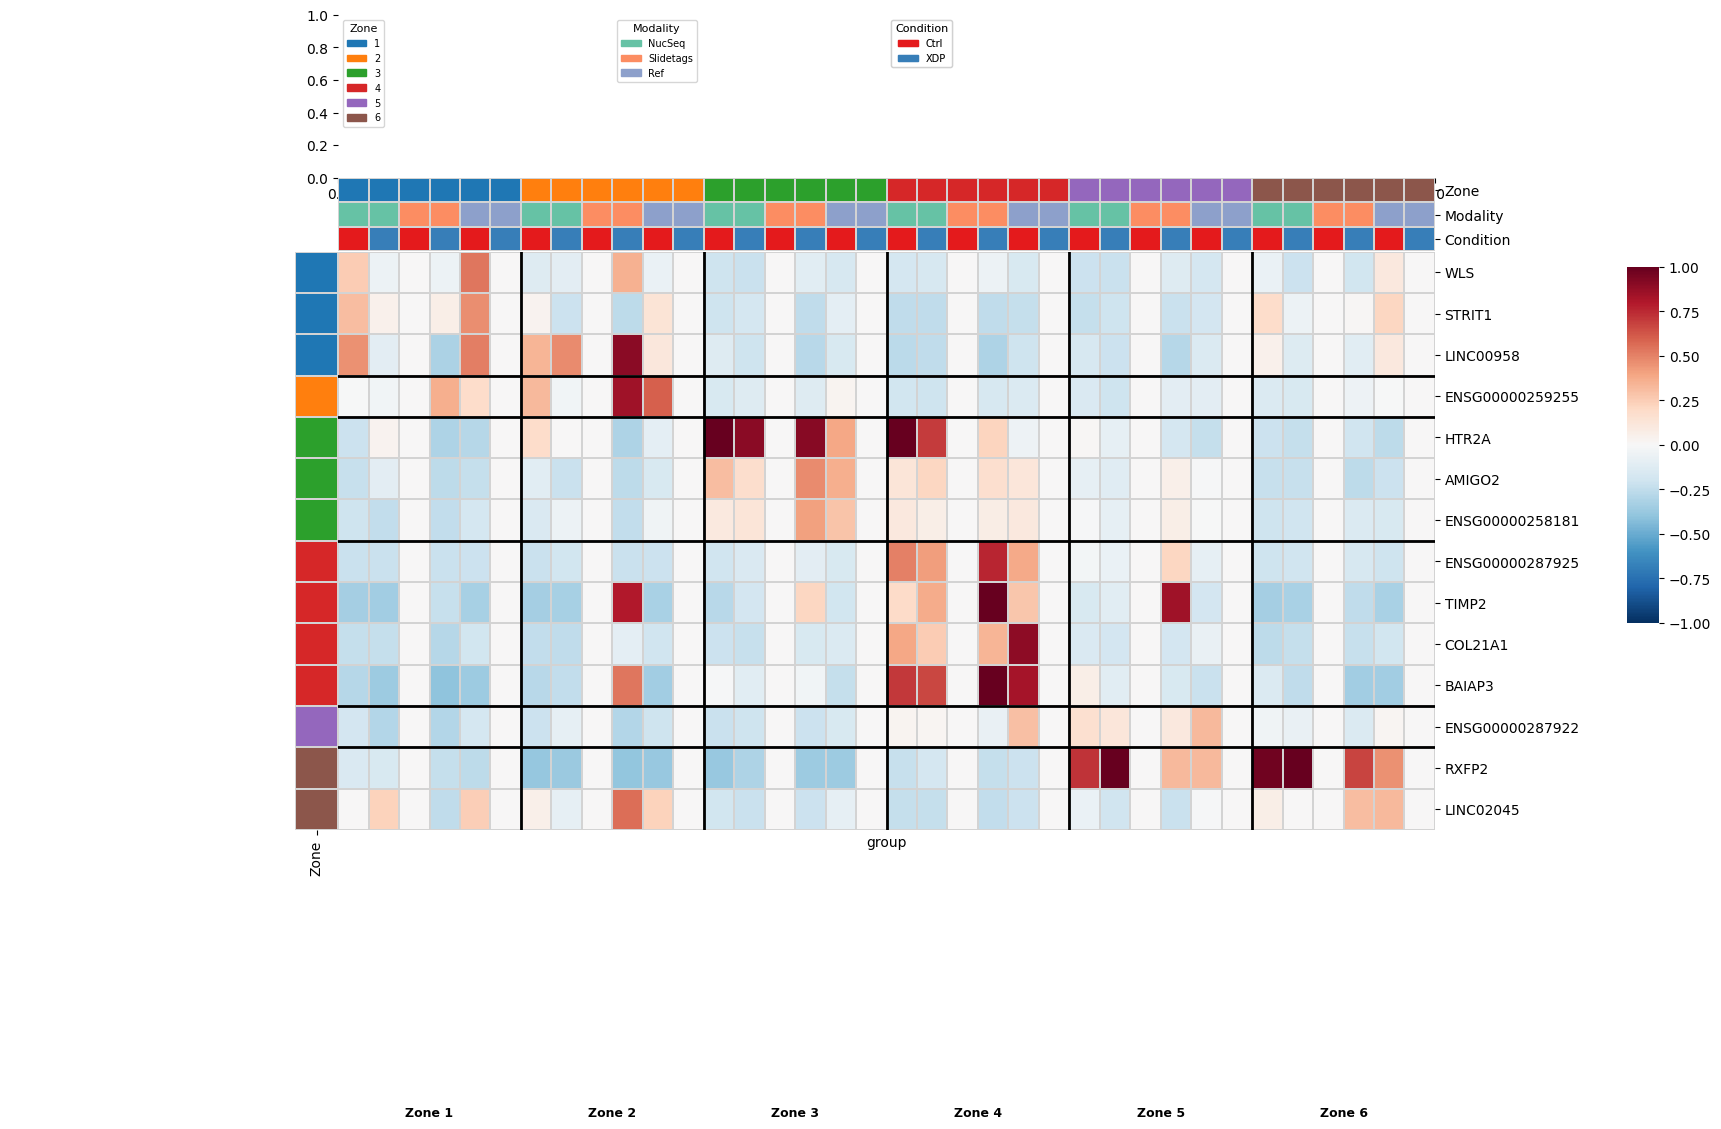

In [104]:
MODALITIES = ["NucSeq", "Slidetags", "Ref"]
N_PER_ZONE = len(MODALITIES) * 2  # 6: NucSeq_H, NucSeq_D, Slidetags_H, Slidetags_D, Ref_H, Ref_D

# ── MARKERS: remove genes not in adata ───────────────────────────────────────
zone_markers_dict = ast.literal_eval(os.getenv("ZONE_MARKERS_D1_MATRIX"))
adata_genes       = set(combined.var_names)
zone_markers_dict = {z: [g for g in genes if g in adata_genes] for z, genes in zone_markers_dict.items()}
zone_markers_dict = {z: genes for z, genes in zone_markers_dict.items() if genes}
all_markers       = [g for genes in zone_markers_dict.values() for g in genes]

# ── MEAN scaled expression per group ─────────────────────────────────────────
expr_df          = sc.get.obs_df(combined, keys=all_markers, layer="scaled", gene_symbols="gene_symbol")
expr_df["group"] = combined.obs["group"].values
mean_scaled      = expr_df.groupby("group")[all_markers].mean()

# ── ENSURE all zone × modality × condition combinations exist ─────────────────
zones          = sorted(combined.obs[ZONE_COL].astype(str).unique(), key=str)
ordered_groups = [f"{z}_{m}_{c}" for z, m, c in product(zones, MODALITIES, [HEALTHY_LABEL, DISEASE_LABEL])]
missing        = [g for g in ordered_groups if g not in mean_scaled.index]
print(f"Missing groups (filled with 0): {missing}")
mean_scaled    = mean_scaled.reindex(ordered_groups, fill_value=0)

# ── METADATA ──────────────────────────────────────────────────────────────────
COL_PALETTES = {
    "Zone"      : "tab10",
    "Modality"  : "Set2",
    "Condition" : "Set1",
}

def make_col_colors(meta, categorical_cols, numeric_cols=[], col_palettes={}):
    col_colors = {}

    for col in categorical_cols:
        series  = meta[col].astype(str)
        palette_name = col_palettes.get(col, "tab10")  # fallback to tab10
        palette = dict(zip(series.unique(), sns.color_palette(palette_name, series.nunique())))
        col_colors[col] = series.map(palette)

    for col in numeric_cols:
        series = meta[col].astype(float)
        norm   = mcolors.Normalize(vmin=series.min(), vmax=series.max())
        cmap_name = col_palettes.get(col, "viridis")   # fallback to viridis
        cmap   = mcolors.get_cmap(cmap_name)
        col_colors[col] = series.map(lambda v: cmap(norm(v)))

    return pd.DataFrame(col_colors, index=meta.index)

sample_meta              = pd.DataFrame(index=ordered_groups)
sample_meta["Zone"]      = [g.split("_")[0] for g in ordered_groups]
sample_meta["Modality"]  = [g.split("_")[1] for g in ordered_groups]
sample_meta["Condition"] = [g.split("_")[2] for g in ordered_groups]
col_colors               = make_col_colors(sample_meta, ["Zone", "Modality", "Condition"], col_palettes=COL_PALETTES)

# ── ROW colors (gene → zone) ──────────────────────────────────────────────────
gene_to_zone = {g: z for z, genes in zone_markers_dict.items() for g in genes}
zone_palette = dict(zip(sorted(set(gene_to_zone.values())), sns.color_palette("tab10", len(zone_markers_dict))))
row_colors   = pd.Series(all_markers).map(gene_to_zone).map(zone_palette).rename("Zone").set_axis(all_markers)

# ── CLUSTERMAP ────────────────────────────────────────────────────────────────
g = sns.clustermap(
    mean_scaled.T,
    row_cluster=False, col_cluster=False,
    col_colors=col_colors, row_colors=row_colors,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    figsize=(16, len(all_markers) * 0.35 + 4),
    xticklabels=False, yticklabels=True,
    cbar_pos=(1.02, 0.3, 0.02, 0.4),
    linewidths=0.2, linecolor="lightgrey",
)

# ── LEGENDS ───────────────────────────────────────────────────────────────────
legend_ax = g.ax_col_dendrogram
legend_ax.clear()
for i, col in enumerate(["Zone", "Modality", "Condition"]):
    series       = sample_meta[col].astype(str)
    palette_name = COL_PALETTES.get(col, "tab10")   # ← use COL_PALETTES
    palette      = dict(zip(series.unique(), sns.color_palette(palette_name, series.nunique())))
    handles      = [mpatches.Patch(color=c, label=k) for k, c in palette.items()]
    leg = legend_ax.legend(handles=handles, title=col, bbox_to_anchor=(i * 0.25, 1),
                            loc="upper left", fontsize=7, title_fontsize=8)
    legend_ax.add_artist(leg)

# ── DIVIDERS ──────────────────────────────────────────────────────────────────
ax = g.ax_heatmap

# Vertical: split zones
for z_idx in range(1, len(zones)):
    ax.axvline(z_idx * N_PER_ZONE, color="black", linewidth=2)
for z_idx, zone in enumerate(zones):
    ax.text(z_idx * N_PER_ZONE + N_PER_ZONE / 2, -0.5, f"Zone {zone}",
            ha="center", va="bottom", fontsize=9, fontweight="bold",
            transform=ax.get_xaxis_transform())

# Horizontal: split where gene zone changes
prev_zone = None
for i, gene in enumerate(all_markers):
    curr_zone = gene_to_zone[gene]
    if curr_zone != prev_zone and prev_zone is not None:
        ax.axhline(i, color="black", linewidth=2)
    prev_zone = curr_zone

plt.savefig("clustermap.pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_103860/376923171.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined.obs.groupby("group")


Text(469.2263071895425, 0.5, '# cells')

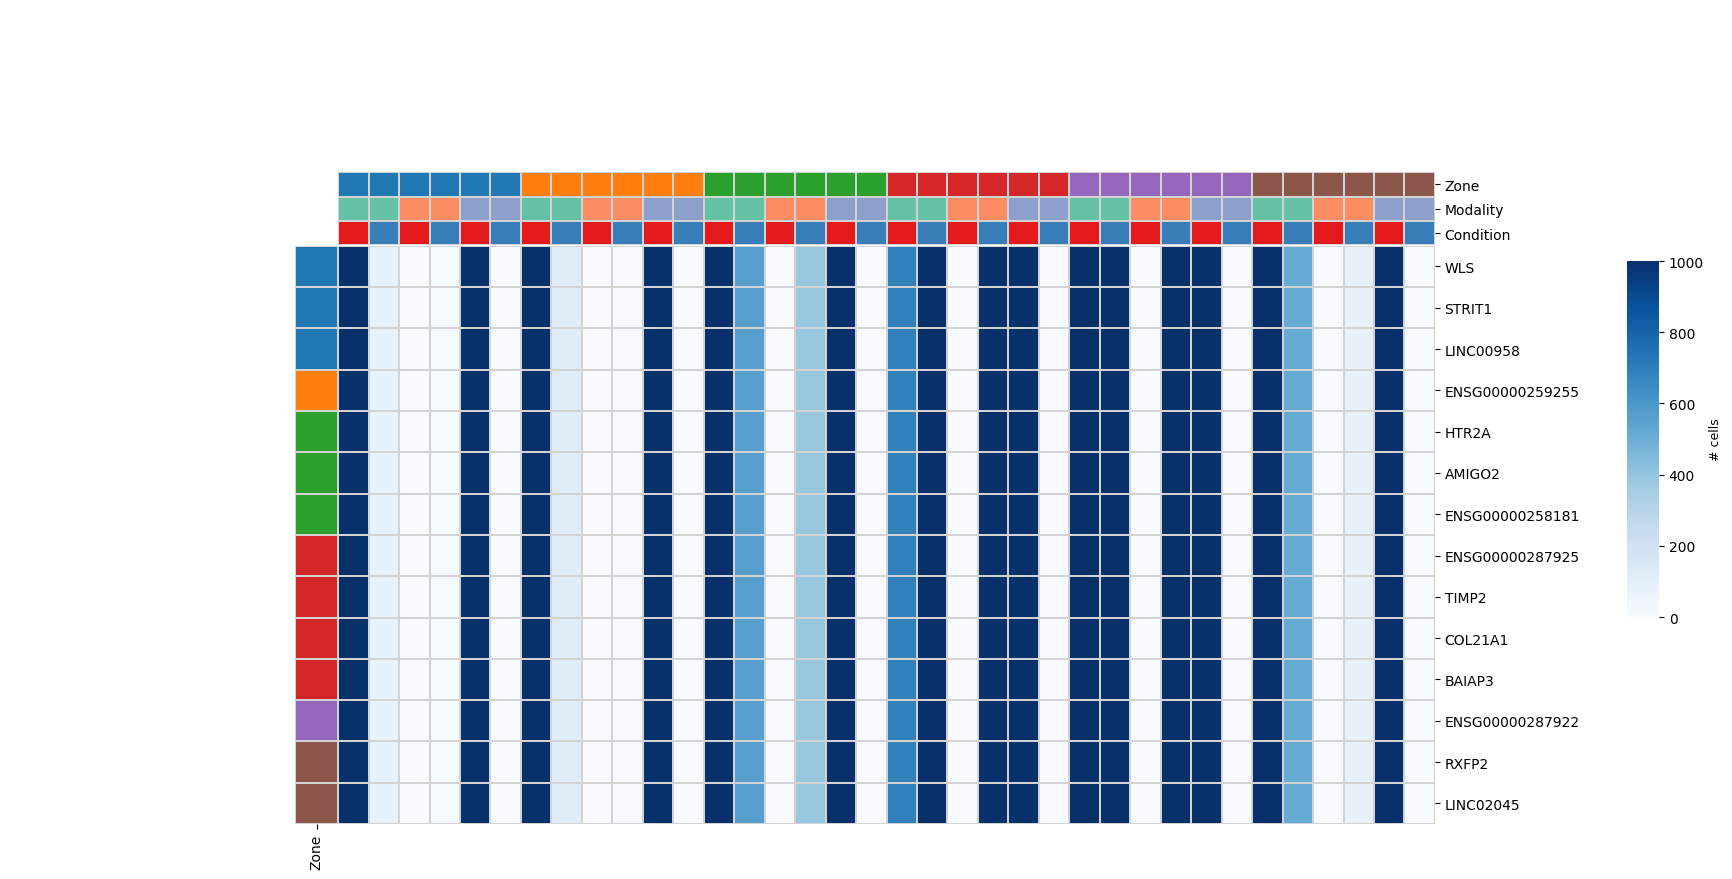

In [100]:
# ── CELL COUNTS per group ─────────────────────────────────────────────────────
count_df = (
    combined.obs.groupby("group")
    .size()
    .reindex(ordered_groups, fill_value=0)
    .to_frame(name="n_cells")
)

# ── MAKE A UNIFORM MATRIX (same shape as mean_scaled) filled with n_cells ─────
# Each gene column gets the same value = n_cells for that group
count_matrix = pd.DataFrame(
    {gene: count_df["n_cells"] for gene in all_markers},
    index=ordered_groups
)

# ── CLUSTERMAP ────────────────────────────────────────────────────────────────
g = sns.clustermap(
    count_matrix.T,
    row_cluster=False, col_cluster=False,
    col_colors=col_colors, row_colors=row_colors,
    cmap="Blues", center=None, vmin=0,  vmax=1000, # ← no centering, sequential colormap
    figsize=(16, len(all_markers) * 0.35 + 4),
    xticklabels=False, yticklabels=True,
    cbar_pos=(1.02, 0.3, 0.02, 0.4),
    linewidths=0.2, linecolor="lightgrey",
)
g.cax.set_ylabel("# cells", fontsize=9)